# Chicago Airbnb Market Analysis

## 1: Introduction

Chicago's short-term rental market has exploded over the past decade, with thousands of Airbnb listings competing for guests across 70+ neighborhoods. For a real estate investor considering entering this market, the key questions are straightforward but critical: which neighborhoods offer the best return, what type of property should you buy, and how should you price it? This analysis uses SQL to explore over 10,000 Chicago Airbnb listings, examining pricing patterns, guest satisfaction, seasonal demand, and host performance to build a data-driven investment strategy. Rather than relying on gut instinct or anecdotal advice, we'll let the data reveal where the real opportunities are hiding.

## 2: Data Collection & Database Setup

In [39]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Load CSVs into pandas
listings = pd.read_csv("/content/drive/MyDrive/listings.csv.gz")
reviews = pd.read_csv("/content/drive/MyDrive/reviews.csv.gz")

# Removing dollar signs and commas from pricing data to allow for calculations
listings['price'] = listings['price'].str.replace('$', '').str.replace(',', '').astype(float)

# Removing hotels
listings = listings[listings['room_type'] != 'Hotel room']

# Create a SQLite database
conn = sqlite3.connect("airbnb_chicago.db")

listings.to_sql("listings", conn, if_exists="replace", index=False)
reviews.to_sql("reviews", conn, if_exists="replace", index=False)

492465

Hotel room listings (69 total) were removed from the analysis due
to unreliable pricing data and irrelevance to the residential
investment focus of this project.

## 3: Data Exploration

Before diving into analysis, we need to understand the shape of the data we're working with. How many listings are in the Chicago market? What types of properties are available? What does the price distribution look like? These baseline questions help us spot data quality issues early and give us the context we need to interpret the deeper analysis that follows.

In [40]:
# Number of listings in listings table
pd.read_sql(""" SELECT COUNT(*) AS total_listings
                FROM listings """, conn)

,total_listings
0,8543


In [41]:
# Columns in listings table
pd.read_sql(""" PRAGMA table_info(listings) """, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,0
1,1,listing_url,TEXT,0,None,0
2,2,scrape_id,INTEGER,0,None,0
3,3,last_scraped,TEXT,0,None,0
4,4,source,TEXT,0,None,0
...,...,...,...,...,...,...
74,74,calculated_host_listings_count,INTEGER,0,None,0
75,75,calculated_host_listings_count_entire_homes,INTEGER,0,None,0
76,76,calculated_host_listings_count_private_rooms,INTEGER,0,None,0
77,77,calculated_host_listings_count_shared_rooms,INTEGER,0,None,0


In [42]:
# Types of listings in listings table
pd.read_sql("""
SELECT room_type, COUNT(*) AS count
FROM listings
GROUP BY room_type
ORDER BY count DESC """, conn)

,room_type,count
0,Entire home/apt,6668
1,Private room,1839
2,Shared room,36


In [43]:
# Number of neighborhoods in listings table
pd.read_sql(""" SELECT COUNT(DISTINCT neighbourhood_cleansed) AS num_neighborhoods
                FROM listings """, conn)

,num_neighborhoods
0,76


In [44]:
# Minimum, maximum and average price
pd.read_sql("""
SELECT
    MIN(price) AS min_price,
    MAX(price) AS max_price,
    AVG(price) AS avg_price,
    COUNT(*) AS total
FROM listings """, conn)

,min_price,max_price,avg_price,total
0,13.0,50000.0,386.016245,8543


In [45]:
# Median price
pd.read_sql("""
    SELECT ROUND(price, 2) AS median_price
    FROM (
        SELECT price
        FROM listings
        ORDER BY price
        LIMIT 1
        OFFSET (SELECT COUNT(*) FROM listings) / 2
    )
""", conn)

,median_price
0,139.0


The Chicago Airbnb market includes 8,543 active listings across 76 of the city's 77 neighborhoods (after removing 69 hotel room listings due to unreliable data). The market is dominated by entire home/apartment listings (6,668, or 78%), with private rooms making up most of the remainder (1,839). Shared rooms are a small niche with just 36 listings. Prices range from \$13 to \$50,000 per night, with a median price of \$139. The mean price of \$386 is significantly higher due to a small number of luxury outliers pulling it upward — a classic example of right-skewed pricing data where the median provides a more accurate picture of the typical listing.

## 4: Analysis Queries

### Query 1: Which neighborhoods are most expensive?

In [46]:
result = pd.read_sql("""
    SELECT
        neighbourhood_cleansed AS neighbourhood,
        price,
        review_scores_rating
    FROM listings """, conn)

q1_result = result.groupby('neighbourhood').agg(
    num_listings=('price', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_rating=('review_scores_rating', 'mean')
).query('num_listings >= 10').sort_values('median_price', ascending=False).head(15).round(2)

q1_result = q1_result.reset_index()
q1_result

,neighbourhood,num_listings,avg_price,median_price,avg_rating
0,Near North Side,901,1490.02,234.0,4.69
1,Loop,479,948.28,223.0,4.72
2,Near South Side,251,253.83,213.0,4.73
3,Lincoln Park,269,281.69,209.0,4.81
4,Near West Side,559,252.86,206.0,4.76
5,Roseland,21,180.81,185.0,4.50
6,Auburn Gresham,26,169.92,178.0,4.65
7,Lake View,518,246.53,171.5,4.83
8,Clearing,11,227.91,167.0,4.46
9,West Town,692,290.89,165.0,4.84


#### Query 1 Takeaway:
The Near North Side and Loop are Chicago's most expensive Airbnb neighborhoods, with median prices of \$234 and \$223 per night — both central downtown areas popular with tourists and business travelers. The mean-median gap remains large in these neighborhoods (Near North Side averages \$1,490 vs \$234 median), confirming that luxury outliers are concentrated downtown. Notably, the most expensive neighborhoods don't have the best ratings — West Town (4.84), Lake View (4.83), and North Center (4.85) all rate higher than the downtown areas while offering significantly lower median prices. For an investor, neighborhoods like Lincoln Park, Lake View, and Near West Side stand out as a middle ground — strong prices (\$172, \$209, \$206 medians) with solid ratings and high listing counts suggesting proven demand.

### Query 2: What room type gives the best return?

In [47]:
q2_result = pd.read_sql("""
    SELECT
        room_type,
        price,
        number_of_reviews,
        review_scores_rating
    FROM listings """, conn)

q2_result.groupby('room_type').agg(
    num_listings=('price', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_reviews=('number_of_reviews', 'mean'),
    avg_rating=('review_scores_rating', 'mean')
).sort_values('median_price', ascending=False).round(2)

,num_listings,avg_price,median_price,avg_reviews,avg_rating
room_type,,,,,
Entire home/apt,6200,246.53,177.0,59.69,4.79
Private room,1523,961.22,60.0,49.48,4.67
Shared room,33,45.18,38.0,41.53,4.65


#### Query 2 Takeaway:

Entire home/apartment listings are the strongest investment option across nearly every metric. At a median price of \$177/night — nearly 3x that of private rooms (\$60) — they also generate the most reviews (60 avg) and the highest ratings (4.79). The private room average price of \$961 is wildly inflated by outliers, but the median of \$60 tells the real story: private rooms are a budget product with decent demand but far less revenue potential. Shared rooms barely register with only 33 listings. For an investor, the data is clear — entire home/apartment listings offer the best combination of pricing power, guest satisfaction, and proven demand.

Note: Note: 787 listings were excluded from this summary due to missing
price, review, or rating data, reducing totals from the full dataset (6,668 / 1,839 / 36).

### Query 3: What makes a listing highly rated?

In [48]:
q3_result = pd.read_sql("""
    SELECT
        CASE
            WHEN review_scores_rating >= 4.8 THEN 'Top Rated (4.8+)'
            WHEN review_scores_rating >= 4.5 THEN 'Good (4.5-4.8)'
            WHEN review_scores_rating >= 4.0 THEN 'Average (4.0-4.5)'
            ELSE 'Below Average (<4.0)'
        END AS rating_tier,
        COUNT(*) AS num_listings,
        ROUND(AVG(price), 2) AS avg_price,
        ROUND(AVG(number_of_reviews), 0) AS avg_reviews
    FROM listings
    WHERE review_scores_rating IS NOT NULL
    GROUP BY rating_tier
    ORDER BY avg_price DESC """, conn)
q3_result

,rating_tier,num_listings,avg_price,avg_reviews
0,Below Average (<4.0),183,1330.12,4.0
1,Average (4.0-4.5),490,389.97,32.0
2,Top Rated (4.8+),4493,264.51,76.0
3,Good (4.5-4.8),1740,199.30,75.0


#### Query 3 Takeaway:
Counter to what you might expect, higher-rated listings actually charge less — top rated listings (4.8+) average \$265/night compared to \$1,330 for below-average listings. This likely reflects the same outlier effect: expensive luxury properties get fewer bookings and therefore fewer reviews, dragging their ratings down. The demand pattern is striking — top rated listings average 76 reviews while below-average listings average just 4, suggesting that well-reviewed properties generate dramatically more bookings. The majority of the market (4,493 listings, or 65%) falls in the top rated tier, meaning guests have high expectations and competition is fierce. For an investor, the takeaway is clear: prioritize guest experience over premium pricing — a well-rated listing at a moderate price will generate far more bookings than an overpriced one with poor reviews.

### Query 4: How does minimum stay affect the market?

In [49]:
q4_result = pd.read_sql("""
    SELECT
        CASE
            WHEN minimum_nights = 1 THEN '1 night'
            WHEN minimum_nights BETWEEN 2 AND 3 THEN '2-3 nights'
            WHEN minimum_nights BETWEEN 4 AND 7 THEN '4-7 nights'
            WHEN minimum_nights BETWEEN 8 AND 30 THEN '8-30 nights'
            ELSE '30+ nights'
        END AS min_stay_category,
        price,
        number_of_reviews
    FROM listings """, conn)

q4_result.groupby('min_stay_category').agg(
    num_listings=('price', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_reviews=('number_of_reviews', 'mean')
).sort_values('median_price', ascending=False).round(2)

,num_listings,avg_price,median_price,avg_reviews
min_stay_category,,,,
30+ nights,2610,189.94,160.0,16.42
4-7 nights,241,242.59,158.0,74.11
2-3 nights,3298,224.79,155.0,83.72
1 night,1484,1133.33,140.0,75.59
8-30 nights,123,134.29,99.0,36.89


#### Query 4 Takeaway:
The 2-3 night minimum is the sweet spot for short-term rentals — these listings lead in average reviews (84) while maintaining a strong median price of \$155/night, suggesting they attract the most consistent bookings. Surprisingly, 30+ night minimums make up a large share of the market (2,610 listings) but generate far fewer reviews (16 avg), indicating these are likely long-term rental conversions operating on Airbnb rather than traditional vacation stays. One-night minimums have the highest average price (\$1,133) but a modest median of \$140, again showing outliers at work. The 8-30 night range has the lowest median price (\$99) and weakest demand (37 avg reviews), falling into an awkward middle ground between short-term vacation stays and long-term rentals. For an investor targeting short-term rental income, a 2-3 night minimum appears to maximize both pricing and booking volume.

### Query 5: Superhost vs Regular Host

In [50]:
q5_result = pd.read_sql("""
    SELECT
        host_is_superhost,
        price,
        number_of_reviews,
        review_scores_rating
    FROM listings
    WHERE host_is_superhost IS NOT NULL """, conn)

q5_result.groupby('host_is_superhost').agg(
    num_listings=('price', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_reviews=('number_of_reviews', 'mean'),
    avg_rating=('review_scores_rating', 'mean')
).round(2)

,num_listings,avg_price,median_price,avg_reviews,avg_rating
host_is_superhost,,,,,
f,3900,538.71,147.0,31.59,4.64
t,3585,232.53,159.0,85.29,4.86


#### Query 5 Takeaway:
Superhosts outperform regular hosts in nearly every metric. They earn a higher median price (\$159 vs \$147), receive nearly 3x as many reviews (85 vs 32), and rate significantly higher (4.86 vs 4.64). The review gap is the most striking finding — superhosts are generating dramatically more bookings, which more than compensates for the modest price premium. With 3,585 superhosts making up nearly half the market, earning this status is clearly achievable and well worth pursuing. For an investor, the path is clear: focus on guest experience to earn superhost status as quickly as possible — the increase in booking volume alone will far outweigh any short-term revenue from charging higher prices with lower ratings.

### Query 6: Top neighborhoods by value (high ratings, reasonable price)

In [51]:
result = pd.read_sql("""
    SELECT
        neighbourhood_cleansed AS neighbourhood,
        price,
        review_scores_rating
    FROM listings
    WHERE review_scores_rating IS NOT NULL """, conn)

q6_result = result.groupby('neighbourhood').agg(
    num_listings=('price', 'count'),
    median_price=('price', 'median'),
    avg_rating=('review_scores_rating', 'mean')
).query('num_listings >= 10 and avg_rating >= 4.7').sort_values(
    'median_price', ascending=True
).head(10).round(2)

q6_result = q6_result.reset_index()
q6_result

,neighbourhood,num_listings,median_price,avg_rating
0,East Side,11,40.0,4.71
1,North Lawndale,48,82.0,4.79
2,North Park,22,94.5,4.88
3,South Lawndale,41,96.0,4.74
4,Norwood Park,37,96.0,4.83
5,Albany Park,62,102.5,4.83
6,Portage Park,77,103.0,4.82
7,Ohare,10,103.0,4.80
8,Hyde Park,83,108.0,4.74
9,Humboldt Park,82,108.5,4.80


#### Query 6 Takeaway:
These are Chicago's hidden gem neighborhoods — all rated 4.7 or above but priced well below the city's \$139 median. Hyde Park stands out as the strongest investment candidate: 83 listings show proven demand, a 4.74 rating signals guest satisfaction, and a \$108 median price offers an affordable entry point near the University of Chicago. Portage Park (77 listings, \$103 median, 4.82 rating) and Albany Park (62 listings, \$103 median, 4.83 rating) are also compelling — strong ratings with enough listings to confirm the market exists. The cheapest neighborhoods on the list like New City (\$32 median) and East Side (\$40 median) have very few listings, making it harder to draw conclusions. For a budget-conscious investor, these mid-tier neighborhoods offer the best value proposition — high guest satisfaction at a fraction of downtown prices, with lower property acquisition costs as well.

### Query 7: Seasonal trends (using reviews as a proxy)

In [52]:
q7_result = pd.read_sql("""
    SELECT
        SUBSTR(date, 6, 2) AS month,
        COUNT(*) AS num_reviews
    FROM reviews
    GROUP BY month
    ORDER BY month """, conn)
q7_result

,month,num_reviews
0,01,21773
1,02,21258
2,03,35264
3,04,36485
4,05,49280
5,06,56652
6,07,56599
7,08,59097
8,09,52514
9,10,45123


#### Query 7 Takeaway:
Chicago's Airbnb demand follows a clear seasonal pattern. Activity ramps up in spring, peaks during the summer months — June, July, and August account for the highest review counts with August leading at 59,097 — then drops sharply through the fall and bottoms out in January and February. This aligns with Chicago's tourism calendar: warm weather, outdoor festivals, and events like Lollapalooza drive summer demand. For an investor, this means pricing should be adjusted seasonally — charge premium rates from May through September when demand is strongest, and consider lowering prices or offering discounts during the winter months to maintain occupancy.

### Query 8: Multi-listing hosts (who are the big operators?)

In [53]:
q8_result = pd.read_sql("""
    SELECT
        host_id,
        host_name,
        price
    FROM listings """, conn)

hosts = q8_result.groupby(['host_id', 'host_name']).agg(
    num_listings=('price', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median')
).query('num_listings >= 5').sort_values('num_listings', ascending=False).head(10).round(2)

hosts

,,num_listings,avg_price,median_price
host_id,host_name,,,
446820235,LuxurybookingsFZE,119,480.94,415.0
248760412,Cloud9,99,797.49,575.0
395498979,Milan,79,268.01,206.0
391945218,Matt,64,218.28,199.5
177188450,Level,54,472.43,240.0
435105119,Sonder (Chicago),45,401.33,355.0
533234561,Tina,45,37.78,36.0
457438194,Anita,44,73.93,74.5
98193524,Jeremy,38,498.97,270.0


#### Query 8 Takeaway:
Chicago's Airbnb market isn't just individual homeowners — it's partly run by professional operators. The top 10 hosts alone control 623 listings, with LuxurybookingsFZE leading at 119 properties. Names like Sonder (Chicago) and Level are recognizable hospitality companies operating at scale, while Cloud9 runs 99 listings at a premium median price of \$575/night. The range of strategies is notable: Tina runs 45 listings at just \$36/night median (likely budget private rooms), while Jeremy operates 38 listings at $270/night. For a new investor, this is important context — you're not just competing with other homeowners, you're competing with professional property managers who have operational efficiencies and brand recognition. However, the fact that individual hosts like Bella and Anita still operate 30-40+ listings successfully suggests there's room to scale without being a major company.

## 5: Visualizations

### Query 1 Visualization

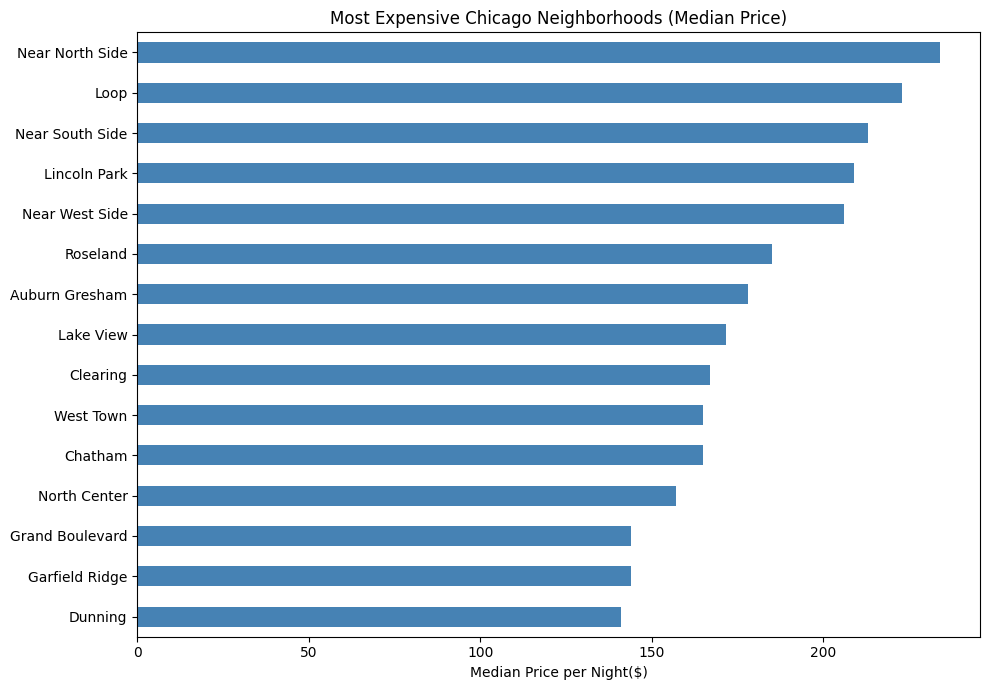

In [54]:
fig, ax = plt.subplots(figsize=(10, 7))
q1_result.sort_values('median_price', ascending=True).plot(
    kind='barh', x='neighbourhood', y='median_price', ax=ax,
    legend=False, color='steelblue')
ax.set_xlabel('Median Price per Night($)')
ax.set_ylabel('')
ax.set_title('Most Expensive Chicago Neighborhoods (Median Price)')
plt.tight_layout()
plt.show()

### Query 6 Visualization

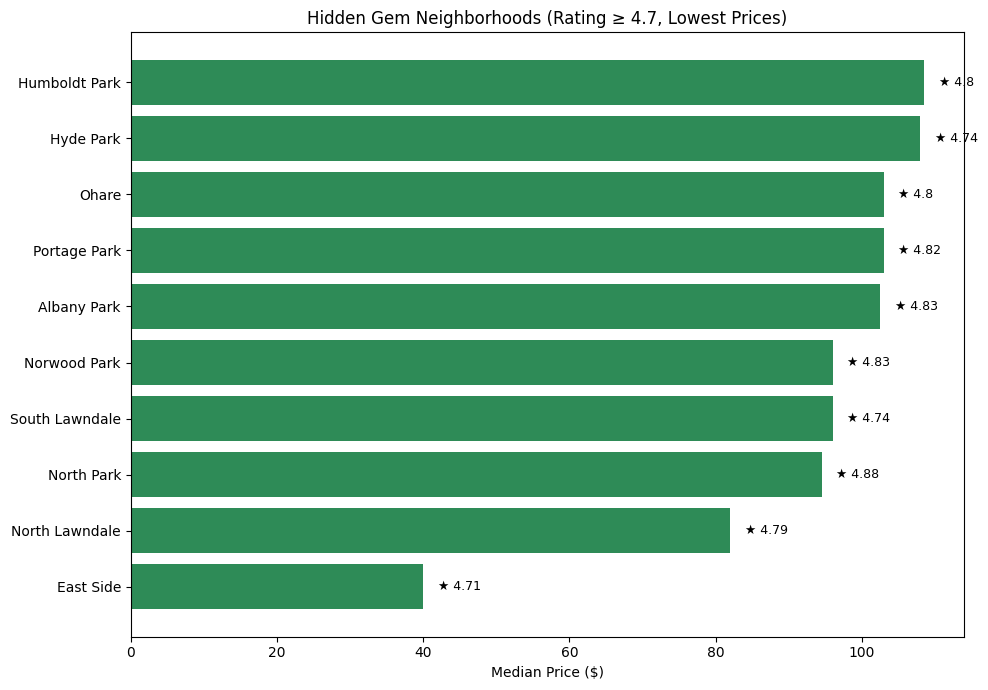

In [55]:
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(q6_result['neighbourhood'], q6_result['median_price'], color='seagreen')

for i, (price, rating) in enumerate(zip(q6_result['median_price'], q6_result['avg_rating'])):
    ax.text(price + 2, i, f'★ {rating}', va='center', fontsize=9)

ax.set_xlabel('Median Price ($)')
ax.set_ylabel('')
ax.set_title('Hidden Gem Neighborhoods (Rating ≥ 4.7, Lowest Prices)')
plt.tight_layout()
plt.show()

### Query 7 Visualization

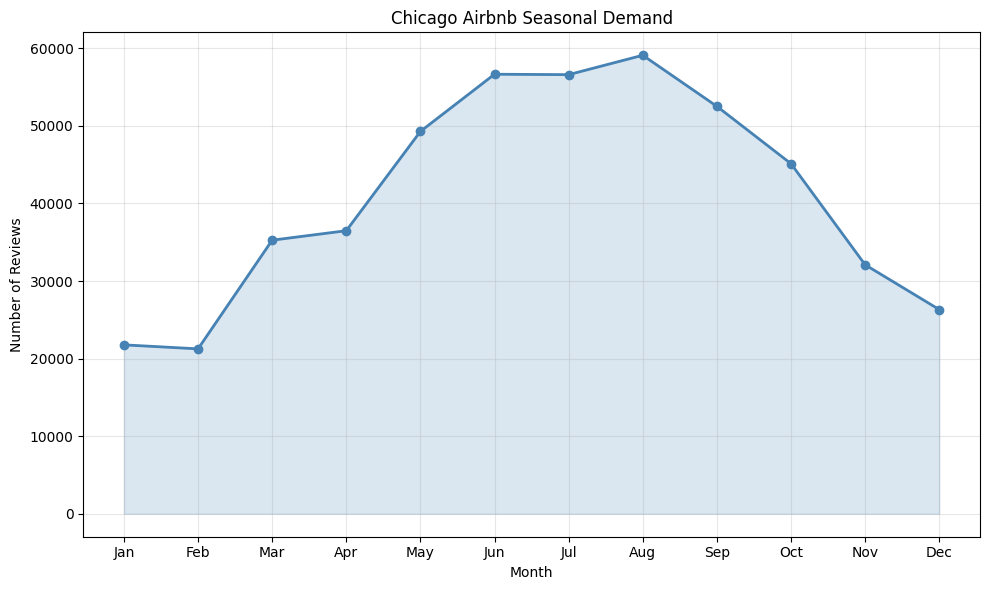

In [57]:
months_abbr = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(months_abbr, q7_result['num_reviews'], marker='o',
        linewidth=2, color='steelblue')
ax.fill_between(months_abbr, q7_result['num_reviews'], alpha=0.2, color='steelblue')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Reviews')
ax.set_title('Chicago Airbnb Seasonal Demand')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6: Key Findings & Investment Recommendations

This analysis explored 8,543 Chicago Airbnb listings to identify
the best investment opportunities in the short-term rental market.
Here are the key takeaways:

1. **Invest in entire home/apartment listings.** They dominate the
   market (78% of listings), command the highest median price
   (\$177/night), generate the most reviews, and receive the best
   ratings. No other room type comes close.

2. **Target hidden gem neighborhoods over downtown.** Areas like
   Hyde Park ($108 median, 4.74 rating), Portage Park (\$103, 4.82),
   and Albany Park (\$103, 4.83) offer strong guest satisfaction at a
   fraction of downtown prices — with lower property acquisition
   costs as well.

3. **Prioritize guest experience over premium pricing.**
   Top-rated listings (4.8+) generate 19x more reviews than
   below-average listings, and superhosts earn nearly 3x the
   reviews of regular hosts. Volume beats price.

4. **Set a 2-3 night minimum stay.** This category leads in
   booking activity (84 avg reviews) while maintaining strong
   pricing (\$155 median). It hits the sweet spot between
   flexibility and revenue.

5. **Price seasonally.** Demand peaks from May through September
   with August as the strongest month. Charge premium rates in
   summer and offer discounts in winter to maintain occupancy.

6. **Be aware of professional competition.** The top 10 hosts
   control 623 listings, including recognizable hospitality
   brands. However, individual hosts still operate successfully
   at scale, suggesting room for new entrants.

## What I'd Do Next
With more data, I would incorporate actual occupancy rates and
revenue figures rather than using reviews as a proxy for demand,
compare Chicago's market to other major cities to identify
relative opportunities, and build a pricing model that accounts
for neighborhood, amenities, seasonality, and competition density.